# Is het verdamping?

In dit experiment is er een verwarmingselement in een met water gevulde maatbeker gestopt. Elke minuut is de temperatuur van het water gemeten. Deze metingen zijn opgeslagen in [tempmetingen.csv](tempmetingen.csv).

Verder is gegeven dat: 
$m_{maatbeker} = 820.8 \mathrm{gr}$  
$m_{maatbeker + water, start} = 1292.9 \mathrm{gr}$  
$m_{maatbeker + water, eind} = 1274.9 \mathrm{gr}$

Het moge duidelijk zijn dat er water is 'verdwenen'. Ook is de eindtemperatuur van het water niet gelijk aan een proces waarbij verdamping en eventuele warmteverliezen niet meegenomen worden. 

```{exercise}
Onderzoek het proces door:
1. De plot van de metingen te maken, inclusief een verwachte trendlijn voor de temperatuur van het water als al de toegevoerde warmte gaat zitten in het water.
2. Bepaal of de totale hoeveelheid toegevoegde energie correspondeert met de opwarming en verdamping van het water, geef daarbij de aannames die je doet.
3. Geef aanbevelingen voor een verbetering van het experiment om (nog) beter het thermodynamische proces te kunnen onderzoeken en beschrijven.
```

2670.6382268984366


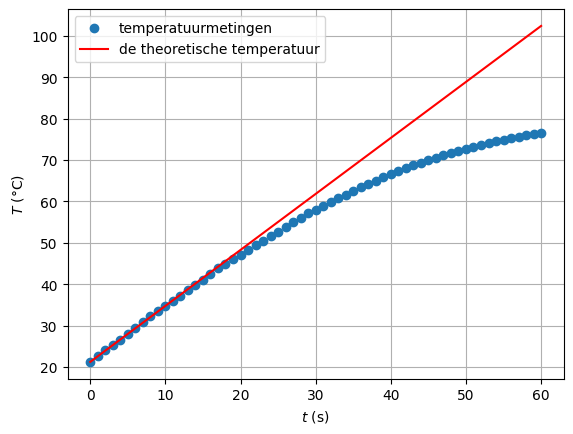

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

data=np.loadtxt('tempmetingen.csv', delimiter=';', skiprows=1)
t=data[:,0]  #in s
T=data[:,1]  #in Celsius

#we gebruiken de formule P*t=c*m*dT:
c=4.18*10**3
m=0.4721 #kg

def T_theorie(t,P):
    return 21.2+(P*t)/(c*m)

popt,pcov=curve_fit(T_theorie,t[:5],T[:5])
P=popt[0]


t_curvefit=np.linspace(0,60,200)

plt.figure()
plt.plot(t,T,'o', label='temperatuurmetingen')
plt.plot(t_test, T_theorie(t_curvefit, P), 'r-', label='de theoretische temperatuur')
plt.xlabel('$t$ (s)')
plt.ylabel('$T$ (°C)')
plt.legend()
plt.grid()
plt.show()

In [8]:
#berekenen massa verschil
E=P*t[-1]
Q_opwarmen=c*m*(T[-1]-T[0])
m_verdampt=1292.9-1274.9
Q_verdampen=m_verdampt*2.26*10**6*10**-3
Q_theorie= Q_opwarmen+Q_verdampen
print('de theoretische warmte is', Q_theorie, 'J')
print('de totale energie is', E, 'J')


de theoretische warmte is 150005.14119999998 J
de totale energie is 160238.2936139062 J


De totale energie die wordt toegevoegd  (160 kJ) is meer dan de theoretische energie die nodig is voor het opwarmen van het water (150 kJ). Dit betekent dat er sprake is van warmteverlies, al is het verschil niet extreem groot: het gaat namelijk om ongeveer 6% verlies. Binnen experimentele onzekerheden is dit een goede overeenkomst. De energiebalans klopt dus redelijk goed met het thermodynamische model.

Het verlies van 6% van de warmte komt mogelijk door warmteverlies aan de omgeving, via convectie, warmtestraling of geleiding. Deze verliezen zijn niet meegenomen in het model. Bovendien is er geen rekening gehouden met de warmtecapaciteit van de maatbeker. De glazen maatbeker zou zelfs al bij een kleine temperatuurstijging enkele duizenden joules kunnen verklaren.

Er zijn verschillende aannames gedaan: dat het vermogen P constant is, dat de temperatuur in het water homogeen is, dat massaverandering door verdamping komt. Hierdoor ontstaan mogelijk meetfouten, waaronder de temperatuurresolutie van de sensor, onzekerheid in massameting en onzekerheid in het gefitte vermogen. 


Eindconclusie:

De totale toegevoerde energie komt vrij goed overeen met de energie die nodig is voor opwarming en verdamping van het water.
De afwijking van 6% komt door warmteverlies en vereenvoudigende aannames.
In de toekomst zou deze afwijking wellicht kunnen worden verkleind door een deksel op de maatbeker te plaatsen, en de maatbeker te laten omgeven met isolatiemateriaal, in plaats van direct in contact te laten staan met de lucht. Hierdoor kunnen warmteverliezen worden verkleind, waardoor die minder invloed hebben en ons model, die hier geen rekening mee houdt, beter overeen komt. 